# Обнаружение мошенничества в банковских транзакциях - ConvMeanMax (Тюнинг)

## Часть 1: Настройка окружения

In [1]:
import logging
import warnings
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler

from sklearn.metrics import (
    roc_auc_score, precision_recall_curve, roc_curve,
    f1_score, fbeta_score, precision_score, recall_score,
    accuracy_score, confusion_matrix, classification_report,
    average_precision_score
)

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")
logger = logging.getLogger(__name__)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

def reset_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

reset_seeds(42)

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
logger.info(f"Окружение инициализировано. Устройство: {device}")

/Users/berdov/project3/fraud_detection/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-05-12 12:15:01,321 - INFO - Окружение инициализировано. Устройство: mps


## Часть 2: Загрузка и подготовка данных

In [2]:
DATA_DIR = Path("../data")

df_train = pd.read_csv(DATA_DIR / "train_clean.csv", index_col=False)
df_val = pd.read_csv(DATA_DIR / "val_clean.csv", index_col=False)
df_test = pd.read_csv(DATA_DIR / "test_clean.csv", index_col=False)

logger.info(f"Тренировочный набор: {df_train.shape[0]:,} транзакций x {df_train.shape[1]} колонок")
logger.info(f"Валидационный набор: {df_val.shape[0]:,} транзакций x {df_val.shape[1]} колонок")
logger.info(f"Тестовый набор: {df_test.shape[0]:,} транзакций x {df_test.shape[1]} колонок")
logger.info(f"Доля мошенничества (тренировка): {df_train['FraudResult'].mean():.2%}")
logger.info(f"Доля мошенничества (валидация): {df_val['FraudResult'].mean():.2%}")
logger.info(f"Доля мошенничества (тест): {df_test['FraudResult'].mean():.2%}")

print("\nСводка данных:")
print(f"  Источник: {DATA_DIR}")
print(f"  Уникальных клиентов (тренировка): {df_train['CustomerId'].nunique():,}")
print(f"  Уникальных клиентов (валидация): {df_val['CustomerId'].nunique():,}")
print(f"  Уникальных клиентов (тест): {df_test['CustomerId'].nunique():,}")
print(f"  Средний размер последовательности: {len(df_train) / df_train['CustomerId'].nunique():.1f} транзакций")

2026-05-12 12:15:01,440 - INFO - Тренировочный набор: 57,364 транзакций x 24 колонок
2026-05-12 12:15:01,441 - INFO - Валидационный набор: 19,162 транзакций x 24 колонок
2026-05-12 12:15:01,441 - INFO - Тестовый набор: 19,136 транзакций x 24 колонок
2026-05-12 12:15:01,443 - INFO - Доля мошенничества (тренировка): 0.20%
2026-05-12 12:15:01,444 - INFO - Доля мошенничества (валидация): 0.21%
2026-05-12 12:15:01,444 - INFO - Доля мошенничества (тест): 0.20%



Сводка данных:
  Источник: ../data
  Уникальных клиентов (тренировка): 2,245
  Уникальных клиентов (валидация): 748
  Уникальных клиентов (тест): 749
  Средний размер последовательности: 25.6 транзакций


## Часть 3: Использование подготовленных признаков и создание последовательностей

In [3]:
FEATURE_COLS = [
    "Amount",
    "abs_amount",
    "log_abs_amount",
    "amount_sign",
    "is_negative_amount",
    "tx_month",
    "tx_day",
    "tx_hour",
    "tx_minute",
    "tx_dayofweek",
    "tx_is_weekend",
    "tx_elapsed_seconds",
    "tx_elapsed_days",
    "tx_hour_sin",
    "tx_hour_cos",
    "tx_dayofweek_sin",
    "tx_dayofweek_cos",
    "ProviderId_id",
    "ProductId_id",
    "ProductCategory_id",
    "ChannelId_id",
    "PricingStrategy_id",
]

TARGET_COL = "FraudResult"
CLIENT_ID_COL = "CustomerId"
SORT_COLS = ["tx_elapsed_seconds", "tx_elapsed_days", "tx_month", "tx_day", "tx_hour", "tx_minute"]

train_features = df_train[[CLIENT_ID_COL, *FEATURE_COLS, TARGET_COL]].copy()
val_features = df_val[[CLIENT_ID_COL, *FEATURE_COLS, TARGET_COL]].copy()
test_features = df_test[[CLIENT_ID_COL, *FEATURE_COLS, TARGET_COL]].copy()

logger.info("Используются признаки, подготовленные в data/cleanup.ipynb")
logger.info(f"Признаков в последовательности: {len(FEATURE_COLS)}")
logger.info(f"Колонки сортировки транзакций: {SORT_COLS}")

2026-05-12 12:15:01,467 - INFO - Используются признаки, подготовленные в data/cleanup.ipynb
2026-05-12 12:15:01,467 - INFO - Признаков в последовательности: 22
2026-05-12 12:15:01,468 - INFO - Колонки сортировки транзакций: ['tx_elapsed_seconds', 'tx_elapsed_days', 'tx_month', 'tx_day', 'tx_hour', 'tx_minute']


### Создание последовательностей для каждого клиента

In [4]:
def create_client_sequences(df, max_seq_len=100, feature_cols=None):
    """
    Организация транзакций в последовательности по клиентам.
    Транзакции внутри каждого клиента сортируются по времени перед обрезкой.
    """
    if feature_cols is None:
        feature_cols = FEATURE_COLS

    sequences = []
    labels = []
    client_ids = []
    available_sort_cols = [col for col in SORT_COLS if col in df.columns]

    for account_id, group in df.groupby(CLIENT_ID_COL, sort=False):
        if available_sort_cols:
            group = group.sort_values(available_sort_cols, kind="mergesort")

        seq = group[feature_cols].values.astype(np.float32)

        if len(seq) > max_seq_len:
            seq = seq[-max_seq_len:]

        if len(seq) < max_seq_len:
            padding = np.zeros((max_seq_len - len(seq), seq.shape[1]), dtype=np.float32)
            seq = np.vstack([padding, seq])

        label = int(group[TARGET_COL].max())

        sequences.append(seq)
        labels.append(label)
        client_ids.append(account_id)

    return np.array(sequences), np.array(labels), np.array(client_ids), list(feature_cols)


logger.info("Создание последовательностей клиентов...")
train_sequences, train_labels, train_clients, feature_cols = create_client_sequences(
    train_features,
    feature_cols=FEATURE_COLS,
)
val_sequences, val_labels, val_clients, _ = create_client_sequences(
    val_features,
    feature_cols=feature_cols,
)
test_sequences, test_labels, test_clients, _ = create_client_sequences(
    test_features,
    feature_cols=feature_cols,
)

logger.info(f"Тренировочные последовательности: {train_sequences.shape}")
logger.info(f"Валидационные последовательности: {val_sequences.shape}")
logger.info(f"Тестовые последовательности: {test_sequences.shape}")
logger.info(f"Распределение меток (тренировка): {np.bincount(train_labels)}")
logger.info(f"Распределение меток (валидация): {np.bincount(val_labels)}")
logger.info(f"Распределение меток (тест): {np.bincount(test_labels)}")
logger.info(f"Всего признаков в последовательности: {len(feature_cols)}")

print(f"\nРазмер последовательностей:")
print(f"  Максимальная длина: 100 транзакций")
print(f"  Размер признаков: {train_sequences.shape[2]}")
print(f"  Клиентов (тренировка): {len(train_sequences)}")
print(f"  Клиентов (валидация): {len(val_sequences)}")
print(f"  Клиентов (тест): {len(test_sequences)}")

2026-05-12 12:15:01,473 - INFO - Создание последовательностей клиентов...
2026-05-12 12:15:03,103 - INFO - Тренировочные последовательности: (2245, 100, 22)
2026-05-12 12:15:03,105 - INFO - Валидационные последовательности: (748, 100, 22)
2026-05-12 12:15:03,105 - INFO - Тестовые последовательности: (749, 100, 22)
2026-05-12 12:15:03,106 - INFO - Распределение меток (тренировка): [2213   32]
2026-05-12 12:15:03,106 - INFO - Распределение меток (валидация): [737  11]
2026-05-12 12:15:03,106 - INFO - Распределение меток (тест): [738  11]
2026-05-12 12:15:03,106 - INFO - Всего признаков в последовательности: 22



Размер последовательностей:
  Максимальная длина: 100 транзакций
  Размер признаков: 22
  Клиентов (тренировка): 2245
  Клиентов (валидация): 748
  Клиентов (тест): 749


### Нормализация признаков

In [5]:
n_clients, seq_len, n_features = train_sequences.shape
training_reshaped = train_sequences.reshape(-1, n_features)

scaler = StandardScaler()
training_scaled_reshaped = scaler.fit_transform(training_reshaped)
training_sequences_scaled = training_scaled_reshaped.reshape(n_clients, seq_len, n_features)

val_reshaped = val_sequences.reshape(-1, n_features)
val_scaled_reshaped = scaler.transform(val_reshaped)
val_sequences_scaled = val_scaled_reshaped.reshape(val_sequences.shape[0], seq_len, n_features)

test_reshaped = test_sequences.reshape(-1, n_features)
test_scaled_reshaped = scaler.transform(test_reshaped)
test_sequences_scaled = test_scaled_reshaped.reshape(test_sequences.shape[0], seq_len, n_features)

logger.info("Признаки нормализованы")
print(f"Нормализация - статистика тренировки:")
print(f"  Mean: {training_sequences_scaled.reshape(-1, n_features).mean(axis=0)[:5]}...")
print(f"  Std:  {training_sequences_scaled.reshape(-1, n_features).std(axis=0)[:5]}...")

2026-05-12 12:15:03,153 - INFO - Признаки нормализованы


Нормализация - статистика тренировки:
  Mean: [-4.3345003e-06 -2.5165941e-06 -9.7838507e-05 -5.6253055e-05
  1.5194544e-04]...
  Std:  [0.9996615 0.9996004 1.0007588 1.0006154 0.9976402]...


### Преобразование в PyTorch tensors

In [6]:
X_train_tensor = torch.FloatTensor(training_sequences_scaled)
y_train_tensor = torch.LongTensor(train_labels)

X_val_tensor = torch.FloatTensor(val_sequences_scaled)
y_val_tensor = torch.LongTensor(val_labels)

X_test_tensor = torch.FloatTensor(test_sequences_scaled)
y_test_tensor = torch.LongTensor(test_labels)

logger.info(f"Тренировочные тензоры: {X_train_tensor.shape}")
logger.info(f"Валидационные тензоры: {X_val_tensor.shape}")
logger.info(f"Тестовые тензоры: {X_test_tensor.shape}")

2026-05-12 12:15:03,172 - INFO - Тренировочные тензоры: torch.Size([2245, 100, 22])
2026-05-12 12:15:03,173 - INFO - Валидационные тензоры: torch.Size([748, 100, 22])
2026-05-12 12:15:03,173 - INFO - Тестовые тензоры: torch.Size([749, 100, 22])


## Часть 4: Архитектуры сверточных моделей для последовательностей

In [7]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, dropout=0.2, dilation=1):
        super().__init__()
        padding = dilation * (kernel_size // 2)
        self.block = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size, padding=padding, dilation=dilation),
            nn.BatchNorm1d(out_channels),
            nn.GELU(),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.block(x)


class ResidualConvBlock(nn.Module):
    def __init__(self, channels, kernel_size=3, dropout=0.2, dilation=1):
        super().__init__()
        padding = dilation * (kernel_size // 2)
        self.conv1 = nn.Conv1d(channels, channels, kernel_size, padding=padding, dilation=dilation)
        self.bn1 = nn.BatchNorm1d(channels)
        self.conv2 = nn.Conv1d(channels, channels, kernel_size, padding=padding, dilation=dilation)
        self.bn2 = nn.BatchNorm1d(channels)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        residual = x
        x = F.gelu(self.bn1(self.conv1(x)))
        x = self.dropout(x)
        x = self.bn2(self.conv2(x))
        return F.gelu(x + residual)


class ConvMeanClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=3, kernel_size=3, dropout=0.2, num_classes=2):
        super().__init__()
        layers = [ConvBlock(input_dim, hidden_dim, kernel_size=kernel_size, dropout=dropout)]
        for _ in range(num_layers - 1):
            layers.append(ConvBlock(hidden_dim, hidden_dim, kernel_size=kernel_size, dropout=dropout))
        self.encoder = nn.Sequential(*layers)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.encoder(x)
        pooled = x.mean(dim=2)
        return self.classifier(pooled)


class ConvMaxClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=3, kernel_size=3, dropout=0.2, num_classes=2):
        super().__init__()
        layers = [ConvBlock(input_dim, hidden_dim, kernel_size=kernel_size, dropout=dropout)]
        for _ in range(num_layers - 1):
            layers.append(ConvBlock(hidden_dim, hidden_dim, kernel_size=kernel_size, dropout=dropout))
        self.encoder = nn.Sequential(*layers)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.encoder(x)
        pooled = x.max(dim=2).values
        return self.classifier(pooled)


class ConvMeanMaxClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=3, kernel_size=3, dropout=0.2, num_classes=2):
        super().__init__()
        layers = [ConvBlock(input_dim, hidden_dim, kernel_size=kernel_size, dropout=dropout)]
        for _ in range(num_layers - 1):
            layers.append(ConvBlock(hidden_dim, hidden_dim, kernel_size=kernel_size, dropout=dropout))
        self.encoder = nn.Sequential(*layers)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.encoder(x)
        mean_pool = x.mean(dim=2)
        max_pool = x.max(dim=2).values
        return self.classifier(torch.cat([mean_pool, max_pool], dim=1))


class ResidualCNNClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=4, kernel_size=3, dropout=0.2, num_classes=2):
        super().__init__()
        self.input_proj = ConvBlock(input_dim, hidden_dim, kernel_size=kernel_size, dropout=dropout)
        self.blocks = nn.Sequential(*[
            ResidualConvBlock(hidden_dim, kernel_size=kernel_size, dropout=dropout)
            for _ in range(num_layers)
        ])
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.input_proj(x)
        x = self.blocks(x)
        pooled = torch.cat([x.mean(dim=2), x.max(dim=2).values], dim=1)
        return self.classifier(pooled)


class DilatedCNNClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, kernel_size=3, dropout=0.2, num_classes=2):
        super().__init__()
        self.encoder = nn.Sequential(
            ConvBlock(input_dim, hidden_dim, kernel_size=kernel_size, dropout=dropout, dilation=1),
            ConvBlock(hidden_dim, hidden_dim, kernel_size=kernel_size, dropout=dropout, dilation=2),
            ConvBlock(hidden_dim, hidden_dim, kernel_size=kernel_size, dropout=dropout, dilation=4),
            ConvBlock(hidden_dim, hidden_dim, kernel_size=kernel_size, dropout=dropout, dilation=8),
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.encoder(x)
        pooled = torch.cat([x.mean(dim=2), x.max(dim=2).values], dim=1)
        return self.classifier(pooled)


class CNNAttentionClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=3, kernel_size=3, dropout=0.2, num_classes=2):
        super().__init__()
        layers = [ConvBlock(input_dim, hidden_dim, kernel_size=kernel_size, dropout=dropout)]
        for _ in range(num_layers - 1):
            layers.append(ConvBlock(hidden_dim, hidden_dim, kernel_size=kernel_size, dropout=dropout))
        self.encoder = nn.Sequential(*layers)
        self.attention = nn.Sequential(
            nn.Conv1d(hidden_dim, hidden_dim, kernel_size=1),
            nn.Tanh(),
            nn.Conv1d(hidden_dim, 1, kernel_size=1),
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 3, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.encoder(x)
        attn_weights = torch.softmax(self.attention(x), dim=2)
        attn_pool = (x * attn_weights).sum(dim=2)
        mean_pool = x.mean(dim=2)
        max_pool = x.max(dim=2).values
        return self.classifier(torch.cat([attn_pool, mean_pool, max_pool], dim=1))

## Часть 5: Подбор гиперпараметров с Optuna

In [8]:
MODEL_NAME = "ConvMeanMax"
MODEL_CLASS = ConvMeanMaxClassifier

n_trials = 50
num_epochs = 100
patience = 15


def suggest_model_params(trial):
    params = {
        "hidden_dim": trial.suggest_categorical("hidden_dim", [32, 48, 64, 96, 128, 160]),
        "kernel_size": trial.suggest_categorical("kernel_size", [3, 5, 7]),
        "dropout": trial.suggest_float("dropout", 0.1, 0.6, step=0.1),
    }
    params["num_layers"] = trial.suggest_int("num_layers", 2, 5)

    return params


In [9]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, reduction="none")
        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt) ** self.gamma * ce_loss

        if self.alpha is not None:
            alpha_t = self.alpha[targets]
            focal_loss = alpha_t * focal_loss

        return focal_loss.mean()


def make_criterion(trial, criterion_type):
    if criterion_type == "ce":
        return nn.CrossEntropyLoss()

    if criterion_type == "weighted_ce":
        fraud_weight = trial.suggest_float("fraud_weight", 2.0, 30.0)
        class_weights = torch.tensor([1.0, fraud_weight], dtype=torch.float32, device=device)
        return nn.CrossEntropyLoss(weight=class_weights)

    if criterion_type == "focal":
        alpha_fraud = trial.suggest_float("alpha_fraud", 2.0, 30.0)
        gamma = trial.suggest_float("gamma", 1.0, 4.0)
        alpha = torch.tensor([1.0, alpha_fraud], dtype=torch.float32, device=device)
        return FocalLoss(alpha=alpha, gamma=gamma)

    raise ValueError(f"Неизвестная функция потерь: {criterion_type}")


def make_optimizer(model, trial, optimizer_type, learning_rate, weight_decay):
    if optimizer_type == "adam":
        return optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    if optimizer_type == "adamw":
        return optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    if optimizer_type == "sgd":
        momentum = trial.suggest_float("momentum", 0.0, 0.95)
        return optim.SGD(
            model.parameters(),
            lr=learning_rate,
            momentum=momentum,
            weight_decay=weight_decay,
        )

    raise ValueError(f"Неизвестный оптимизатор: {optimizer_type}")


def make_scheduler(optimizer, scheduler_type, num_epochs):
    if scheduler_type == "none":
        return None
    if scheduler_type == "step":
        return optim.lr_scheduler.StepLR(optimizer, step_size=max(num_epochs // 3, 1), gamma=0.5)
    if scheduler_type == "cosine":
        return optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    raise ValueError(f"Неизвестный scheduler: {scheduler_type}")


def train_epoch(model, train_loader, optimizer, criterion, device, clip_grad=1.0):
    model.train()
    total_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()

        if clip_grad > 0:
            nn.utils.clip_grad_norm_(model.parameters(), clip_grad)

        optimizer.step()
        total_loss += loss.item() * X_batch.size(0)

    return total_loss / len(train_loader.dataset)


def predict_on_loader(model, data_loader, device):
    model.eval()
    scores = []
    labels = []

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            logits = model(X_batch)
            probs = torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()
            scores.extend(probs)
            labels.extend(y_batch.numpy())

    return np.array(labels), np.array(scores)


def find_best_threshold(y_true, y_score, beta=0.5):
    thresholds = np.arange(0.0, 1.01, 0.01)
    fbeta_scores = []

    for threshold in thresholds:
        y_pred = (y_score >= threshold).astype(int)
        fbeta_scores.append(fbeta_score(y_true, y_pred, beta=beta, zero_division=0))

    best_idx = int(np.argmax(fbeta_scores))
    return thresholds[best_idx], fbeta_scores[best_idx], thresholds, fbeta_scores


def calculate_metrics(y_true, y_score, threshold):
    y_pred = (y_score >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "ROC-AUC": roc_auc_score(y_true, y_score),
        "PR-AUC": average_precision_score(y_true, y_score),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "F0.5": fbeta_score(y_true, y_pred, beta=0.5, zero_division=0),
        "Specificity": tn / (tn + fp) if (tn + fp) > 0 else 0.0,
        "FPR": fp / (fp + tn) if (fp + tn) > 0 else 0.0,
        "FNR": fn / (fn + tp) if (fn + tp) > 0 else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) > 0 else 0.0,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
    }


In [10]:
def objective(trial):
    reset_seeds(42 + trial.number)

    model_params = suggest_model_params(trial)
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 5e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    optimizer_type = trial.suggest_categorical("optimizer_type", ["adam", "adamw", "sgd"])
    criterion_type = trial.suggest_categorical("criterion_type", ["ce", "weighted_ce", "focal"])
    scheduler_type = trial.suggest_categorical("scheduler_type", ["none", "step", "cosine"])
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64, 128])
    clip_grad = trial.suggest_categorical("clip_grad", [0.5, 1.0, 1.5, 2.0])

    train_loader = DataLoader(
        TensorDataset(X_train_tensor, y_train_tensor),
        batch_size=batch_size,
        shuffle=True,
    )
    val_loader = DataLoader(
        TensorDataset(X_val_tensor, y_val_tensor),
        batch_size=batch_size,
        shuffle=False,
    )

    model = MODEL_CLASS(
        input_dim=n_features,
        num_classes=2,
        **model_params,
    ).to(device)

    criterion = make_criterion(trial, criterion_type)
    optimizer = make_optimizer(model, trial, optimizer_type, learning_rate, weight_decay)
    scheduler = make_scheduler(optimizer, scheduler_type, num_epochs)

    best_f05 = 0.0
    patience_counter = 0

    for epoch in range(num_epochs):
        train_epoch(model, train_loader, optimizer, criterion, device, clip_grad=clip_grad)

        y_val_true, y_val_score = predict_on_loader(model, val_loader, device)
        _, val_f05, _, _ = find_best_threshold(y_val_true, y_val_score)

        if scheduler is not None:
            scheduler.step()

        trial.report(val_f05, step=epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

        if val_f05 > best_f05:
            best_f05 = val_f05
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            break

    return best_f05


sampler = TPESampler(seed=42, n_startup_trials=8)
pruner = MedianPruner(n_startup_trials=8, n_warmup_steps=10)

study = optuna.create_study(
    study_name=f"{MODEL_NAME}_fraud_detection_tuning",
    direction="maximize",
    sampler=sampler,
    pruner=pruner,
)

logger.info(f"Запуск Optuna для {MODEL_NAME}: {n_trials} trials")
study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

best_trial = study.best_trial
best_params = best_trial.params

logger.info("=" * 80)
logger.info(f"Подбор гиперпараметров завершен за {n_trials} trials")
logger.info(f"Лучший F0.5 на валидации: {best_trial.value:.4f}")
logger.info("Оптимальные гиперпараметры:")
for key, value in sorted(best_params.items()):
    if isinstance(value, float):
        logger.info(f"  {key:<22} = {value:.6f}")
    else:
        logger.info(f"  {key:<22} = {value}")
logger.info("=" * 80)


[I 2026-05-12 12:15:03,207] A new study created in memory with name: ConvMeanMax_fraud_detection_tuning
2026-05-12 12:15:03,208 - INFO - Запуск Optuna для ConvMeanMax: 50 trials
Best trial: 0. Best value: 0.847458:   2%|▏         | 1/50 [00:09<07:27,  9.14s/it]

[I 2026-05-12 12:15:12,352] Trial 0 finished with value: 0.847457627118644 and parameters: {'hidden_dim': 48, 'kernel_size': 5, 'dropout': 0.5, 'num_layers': 2, 'learning_rate': 0.0041472250004816365, 'weight_decay': 0.002136832907235877, 'optimizer_type': 'adam', 'criterion_type': 'weighted_ce', 'scheduler_type': 'step', 'batch_size': 128, 'clip_grad': 1.5, 'fraud_weight': 19.011255853240275}. Best is trial 0 with value: 0.847457627118644.


Best trial: 0. Best value: 0.847458:   4%|▍         | 2/50 [00:20<08:17, 10.37s/it]

[I 2026-05-12 12:15:23,595] Trial 1 finished with value: 0.8181818181818182 and parameters: {'hidden_dim': 96, 'kernel_size': 5, 'dropout': 0.1, 'num_layers': 3, 'learning_rate': 1.2382649697023537e-05, 'weight_decay': 0.0043379206974909395, 'optimizer_type': 'adamw', 'criterion_type': 'weighted_ce', 'scheduler_type': 'none', 'batch_size': 64, 'clip_grad': 2.0, 'fraud_weight': 9.597772889669086}. Best is trial 0 with value: 0.847457627118644.


Best trial: 2. Best value: 0.882353:   6%|▌         | 3/50 [00:29<07:31,  9.61s/it]

...

[I 2026-05-12 12:24:59,553] Trial 47 pruned. 


Best trial: 13. Best value: 0.957447:  98%|█████████▊| 49/50 [10:00<00:07,  7.12s/it]

[I 2026-05-12 12:25:04,169] Trial 48 finished with value: 0.9090909090909091 and parameters: {'hidden_dim': 64, 'kernel_size': 3, 'dropout': 0.2, 'num_layers': 2, 'learning_rate': 0.0022702123258403783, 'weight_decay': 0.0035820012154458296, 'optimizer_type': 'adam', 'criterion_type': 'ce', 'scheduler_type': 'cosine', 'batch_size': 64, 'clip_grad': 0.5}. Best is trial 13 with value: 0.9574468085106383.


Best trial: 13. Best value: 0.957447: 100%|██████████| 50/50 [10:21<00:00, 12.44s/it]
2026-05-12 12:25:25,149 - INFO - ================================================================================
2026-05-12 12:25:25,150 - INFO - Подбор гиперпараметров завершен за 50 trials
2026-05-12 12:25:25,150 - INFO - Лучший F0.5 на валидации: 0.9574
2026-05-12 12:25:25,150 - INFO - Оптимальные гиперпараметры:
2026-05-12 12:25:25,150 - INFO -   batch_size             = 64
2026-05-12 12:25:25,150 - INFO -   clip_grad              = 0.500000
2026-05-12 12:25:25,150 - INFO -   criterion_type         = ce
2026-05-12 12:25:25,150 - INFO -   dropout                = 0.200000
2026-05-12 12:25:25,151 - INFO -   hidden_dim             = 128
2026-05-12 12:25:25,151 - INFO -   kernel_size            = 7
2026-05-12 12:25:25,151 - INFO -   learning_rate          = 0.002141
2026-05-12 12:25:25,151 - INFO -   num_layers             = 4
2026-05-12 12:25:25,151 - INFO -   optimizer_type         = adamw
2026-05-

[I 2026-05-12 12:25:25,139] Trial 49 finished with value: 0.8571428571428571 and parameters: {'hidden_dim': 128, 'kernel_size': 7, 'dropout': 0.1, 'num_layers': 4, 'learning_rate': 0.001509998500546757, 'weight_decay': 0.002636739495909641, 'optimizer_type': 'adamw', 'criterion_type': 'focal', 'scheduler_type': 'none', 'batch_size': 16, 'clip_grad': 0.5, 'alpha_fraud': 9.76559582445924, 'gamma': 3.6491779692076207}. Best is trial 13 with value: 0.9574468085106383.


## Часть 6: Обучение финальной модели

In [11]:
model_param_names = [
    "hidden_dim",
    "kernel_size",
    "dropout",
    "num_layers",
]
model_params = {key: best_params[key] for key in model_param_names if key in best_params}

batch_size = best_params["batch_size"]
learning_rate = best_params["learning_rate"]
weight_decay = best_params["weight_decay"]
optimizer_type = best_params["optimizer_type"]
criterion_type = best_params["criterion_type"]
scheduler_type = best_params["scheduler_type"]
clip_grad = best_params["clip_grad"]

if criterion_type == "ce":
    criterion = nn.CrossEntropyLoss()
elif criterion_type == "weighted_ce":
    class_weights = torch.tensor([1.0, best_params["fraud_weight"]], dtype=torch.float32, device=device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
elif criterion_type == "focal":
    alpha = torch.tensor([1.0, best_params["alpha_fraud"]], dtype=torch.float32, device=device)
    criterion = FocalLoss(alpha=alpha, gamma=best_params["gamma"])
else:
    raise ValueError(f"Неизвестная функция потерь: {criterion_type}")

train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=batch_size,
    shuffle=True,
)
val_loader = DataLoader(
    TensorDataset(X_val_tensor, y_val_tensor),
    batch_size=batch_size,
    shuffle=False,
)
test_loader = DataLoader(
    TensorDataset(X_test_tensor, y_test_tensor),
    batch_size=batch_size,
    shuffle=False,
)

reset_seeds(42)
model = MODEL_CLASS(
    input_dim=n_features,
    num_classes=2,
    **model_params,
).to(device)

if optimizer_type == "adam":
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
elif optimizer_type == "adamw":
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
elif optimizer_type == "sgd":
    optimizer = optim.SGD(
        model.parameters(),
        lr=learning_rate,
        momentum=best_params.get("momentum", 0.0),
        weight_decay=weight_decay,
    )
else:
    raise ValueError(f"Неизвестный оптимизатор: {optimizer_type}")

scheduler = make_scheduler(optimizer, scheduler_type, num_epochs)

train_losses = []
val_losses = []
val_pr_auc_scores = []
val_f05_scores = []
best_val_f05 = 0.0
best_threshold_on_val = 0.5
best_state_dict = None
patience_counter = 0

logger.info("Обучение лучшей модели на train с контролем по val...")

for epoch in range(num_epochs):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device, clip_grad=clip_grad)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            val_loss += loss.item() * X_batch.size(0)
    val_loss /= len(val_loader.dataset)

    y_val_true, y_val_score = predict_on_loader(model, val_loader, device)
    val_pr_auc = average_precision_score(y_val_true, y_val_score)
    threshold, val_f05, _, _ = find_best_threshold(y_val_true, y_val_score)

    if scheduler is not None:
        scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_pr_auc_scores.append(val_pr_auc)
    val_f05_scores.append(val_f05)

    if val_f05 > best_val_f05:
        best_val_f05 = val_f05
        best_threshold_on_val = threshold
        best_state_dict = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    if (epoch + 1) % 10 == 0:
        logger.info(
            f"Эпоха {epoch + 1:3d}: "
            f"train_loss={train_loss:.4f}, "
            f"val_loss={val_loss:.4f}, "
            f"val_pr_auc={val_pr_auc:.4f}, "
            f"val_f0.5={val_f05:.4f}, "
            f"lr={optimizer.param_groups[0]['lr']:.6f}"
        )

    if patience_counter >= patience:
        logger.info(f"Ранняя остановка на эпохе {epoch + 1}")
        break

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)
    model.to(device)

logger.info(f"Обучение завершено. Лучший F0.5 валидации: {best_val_f05:.4f}")
logger.info(f"Лучший порог по валидации: {best_threshold_on_val:.2f}")


2026-05-12 12:25:25,209 - INFO - Обучение лучшей модели на train с контролем по val...
2026-05-12 12:25:32,399 - INFO - Эпоха  10: train_loss=0.0246, val_loss=0.0234, val_pr_auc=0.8464, val_f0.5=0.8571, lr=0.002141
2026-05-12 12:25:40,647 - INFO - Эпоха  20: train_loss=0.0165, val_loss=0.0248, val_pr_auc=0.8233, val_f0.5=0.7937, lr=0.002141
2026-05-12 12:25:51,150 - INFO - Эпоха  30: train_loss=0.0118, val_loss=0.0373, val_pr_auc=0.7893, val_f0.5=0.7692, lr=0.002141
2026-05-12 12:26:02,184 - INFO - Эпоха  40: train_loss=0.0048, val_loss=0.0175, val_pr_auc=0.8855, val_f0.5=0.8974, lr=0.001070
2026-05-12 12:26:09,559 - INFO - Ранняя остановка на эпохе 47
2026-05-12 12:26:09,610 - INFO - Обучение завершено. Лучший F0.5 валидации: 0.9302
2026-05-12 12:26:09,612 - INFO - Лучший порог по валидации: 0.72


## Часть 7: Визуализация обучения

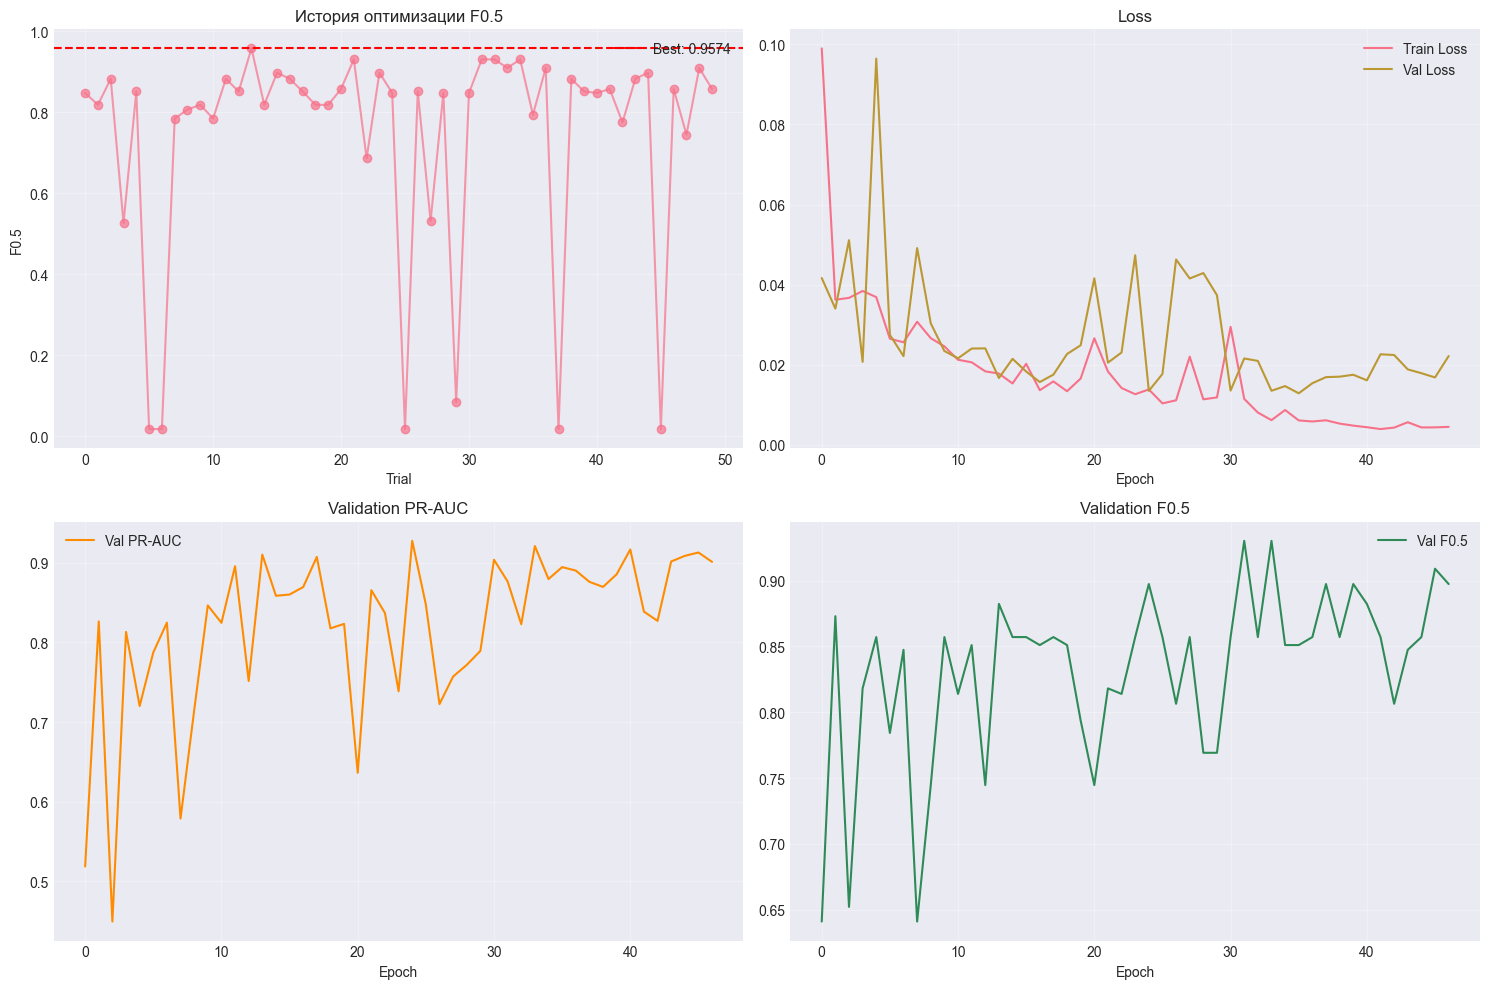

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

trials_df = study.trials_dataframe()

axes[0, 0].plot(trials_df["number"], trials_df["value"], "o-", alpha=0.7)
axes[0, 0].axhline(best_trial.value, color="r", linestyle="--", label=f"Best: {best_trial.value:.4f}")
axes[0, 0].set_title("История оптимизации F0.5")
axes[0, 0].set_xlabel("Trial")
axes[0, 0].set_ylabel("F0.5")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(train_losses, label="Train Loss")
axes[0, 1].plot(val_losses, label="Val Loss")
axes[0, 1].set_title("Loss")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(val_pr_auc_scores, color="darkorange", label="Val PR-AUC")
axes[1, 0].set_title("Validation PR-AUC")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(val_f05_scores, color="seagreen", label="Val F0.5")
axes[1, 1].set_title("Validation F0.5")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Часть 8: Инференс и оценка модели

2026-05-12 12:26:11,477 - INFO - Предсказания получены для 749 клиентов
2026-05-12 12:26:11,478 - INFO - Статистика скоров - min: 0.000001, max: 1.000000, mean: 0.021356
2026-05-12 12:26:11,478 - INFO - Оптимальный порог по validation: 0.72 (лучший F0.5: 0.9302)



        ОТЧЕТ ОБ ОЦЕНКЕ МОДЕЛИ ConvMeanMax (РАСШИРЕННЫЙ ПОДБОР - OPTUNA)        

ТЕМПЛАТА ОПТИМАЛЬНОЙ КОНФИГУРАЦИИ:
--------------------------------------------------------------------------------
  dropout                0.2
  hidden_dim             128
  kernel_size            7
  num_layers             4
  Оптимизатор:           ADAMW (lr=0.002141)
  Scheduler:             STEP
  Batch size:            64
  Clip grad:             0.5
  Функция потерь:        ce

СТАТИСТИКА НАБОРА ДАННЫХ:
--------------------------------------------------------------------------------
  Всего клиентов:                       749    (100.0%)
  Мошенники:                             11    (  1.5%)
  Честные:                              738    ( 98.5%)

РАСПРЕДЕЛЕНИЕ ПРЕДСКАЗАНИЙ:
--------------------------------------------------------------------------------
  Предсказано как мошенник:              8    (  1.1%)
  Предсказано как честный:             741    ( 98.9%)
  Оптимальный порог:             

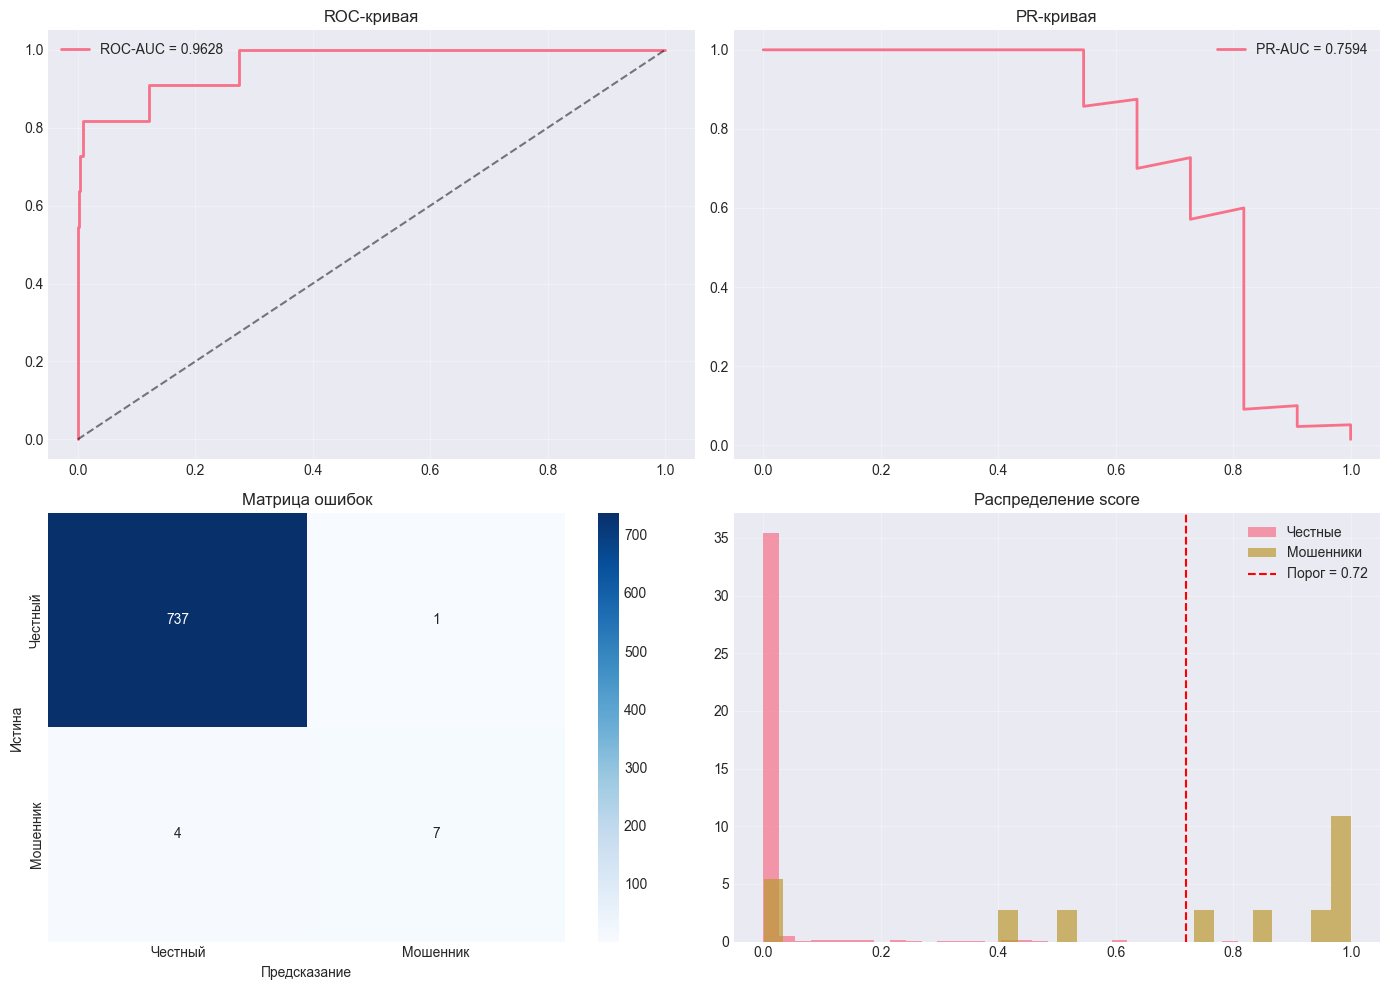

2026-05-12 12:26:11,724 - INFO - Оценка модели завершена успешно


In [13]:
y_true, y_score = predict_on_loader(model, test_loader, device)
optimal_thresh = best_threshold_on_val
y_pred = (y_score >= optimal_thresh).astype(int)

logger.info(f"Предсказания получены для {len(y_score)} клиентов")
logger.info(
    f"Статистика скоров - min: {y_score.min():.6f}, "
    f"max: {y_score.max():.6f}, mean: {y_score.mean():.6f}"
)
logger.info(f"Оптимальный порог по validation: {optimal_thresh:.2f} (лучший F0.5: {best_val_f05:.4f})")

metrics = calculate_metrics(y_true, y_score, optimal_thresh)
tn, fp, fn, tp = metrics["TN"], metrics["FP"], metrics["FN"], metrics["TP"]

print("\n" + "=" * 80)
print(f"ОТЧЕТ ОБ ОЦЕНКЕ МОДЕЛИ {MODEL_NAME} (РАСШИРЕННЫЙ ПОДБОР - OPTUNA)".center(80))
print("=" * 80)

print("\nТЕМПЛАТА ОПТИМАЛЬНОЙ КОНФИГУРАЦИИ:")
print("-" * 80)
for key, value in sorted(model_params.items()):
    print(f"  {key:<22} {value}")
print(f"  Оптимизатор:           {optimizer_type.upper()} (lr={learning_rate:.6f})")
print(f"  Scheduler:             {scheduler_type.upper()}")
print(f"  Batch size:            {batch_size}")
print(f"  Clip grad:             {clip_grad}")
print(f"  Функция потерь:        {criterion_type}")

print("\nСТАТИСТИКА НАБОРА ДАННЫХ:")
print("-" * 80)
n_total = len(y_true)
n_fraud = int((y_true == 1).sum())
n_nonfraud = int((y_true == 0).sum())
print(f"  Всего клиентов:                {n_total:>10,}    ({100.0:>5.1f}%)")
print(f"  Мошенники:                     {n_fraud:>10,}    ({100*n_fraud/n_total:>5.1f}%)")
print(f"  Честные:                       {n_nonfraud:>10,}    ({100*n_nonfraud/n_total:>5.1f}%)")

print("\nРАСПРЕДЕЛЕНИЕ ПРЕДСКАЗАНИЙ:")
print("-" * 80)
n_pred_fraud = int((y_pred == 1).sum())
n_pred_legit = int((y_pred == 0).sum())
print(f"  Предсказано как мошенник:     {n_pred_fraud:>10,}    ({100*n_pred_fraud/n_total:>5.1f}%)")
print(f"  Предсказано как честный:      {n_pred_legit:>10,}    ({100*n_pred_legit/n_total:>5.1f}%)")
print(f"  Оптимальный порог:             {optimal_thresh:>10.4f}")

print("\nМАТРИЦА ОШИБОК:")
print("-" * 80)
print(f"  Истинные негативы (TN):        {tn:>10,}")
print(f"  Ложные позитивы (FP):          {fp:>10,}")
print(f"  Ложные негативы (FN):          {fn:>10,}")
print(f"  Истинные позитивы (TP):        {tp:>10,}")

print("\nМЕТРИКИ КАЧЕСТВА:")
print("-" * 80)
for metric_name, metric_value in sorted(metrics.items()):
    if metric_name in {"TN", "FP", "FN", "TP"}:
        continue
    print(f"  {metric_name:<25} {metric_value:>10.4f}")

print("\nДЕТАЛЬНЫЙ ОТЧЕТ КЛАССИФИКАЦИИ:")
print("-" * 80)
print(classification_report(y_true, y_pred, target_names=["Честный", "Мошенник"], digits=4))

parity_df = pd.DataFrame({"y_true": y_true, "y_score": y_score})
parity_df["bucket"] = pd.cut(
    parity_df["y_score"],
    bins=10,
    labels=[f"{i*0.1:.1f}-{(i+1)*0.1:.1f}" for i in range(10)],
)
parity_stats = parity_df.groupby("bucket", observed=True).agg({
    "y_true": ["count", "sum", "mean"],
    "y_score": ["min", "max", "mean"],
})
parity_stats.columns = ["count", "fraud_count", "fraud_rate", "score_min", "score_max", "score_mean"]

print("\nПАРИТЕТ ПО БАКЕТАМ СКОРА (интервалы 0.1):")
print("-" * 80)
print(parity_stats.round(4).to_string())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

fpr, tpr, _ = roc_curve(y_true, y_score)
axes[0, 0].plot(fpr, tpr, linewidth=2, label=f"ROC-AUC = {metrics['ROC-AUC']:.4f}")
axes[0, 0].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[0, 0].set_title("ROC-кривая")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

precision, recall, _ = precision_recall_curve(y_true, y_score)
axes[0, 1].plot(recall, precision, linewidth=2, label=f"PR-AUC = {metrics['PR-AUC']:.4f}")
axes[0, 1].set_title("PR-кривая")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

sns.heatmap(
    confusion_matrix(y_true, y_pred),
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Честный", "Мошенник"],
    yticklabels=["Честный", "Мошенник"],
    ax=axes[1, 0],
)
axes[1, 0].set_title("Матрица ошибок")
axes[1, 0].set_xlabel("Предсказание")
axes[1, 0].set_ylabel("Истина")

axes[1, 1].hist(y_score[y_true == 0], bins=30, alpha=0.7, label="Честные", density=True)
axes[1, 1].hist(y_score[y_true == 1], bins=30, alpha=0.7, label="Мошенники", density=True)
axes[1, 1].axvline(optimal_thresh, color="red", linestyle="--", label=f"Порог = {optimal_thresh:.2f}")
axes[1, 1].set_title("Распределение score")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

logger.info("Оценка модели завершена успешно")
print("=" * 80)
